# ACLib cplex_regions200: fixed SMAC-surrogate depths

Comparison of random-forest depths **5, 10, 20, and 30** over five paired SMAC seeds. Every run uses the same 100 training instances and 1,000 completed SMAC trials. Lower PAR10 incumbent cost is better.

In [11]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import t
from IPython.display import display

DEPTHS = (5, 10, 20, 30)
SMAC_SEEDS = tuple(range(5))
N_TRIALS = 1_000
N_INSTANCES = 100
COLORS = {5: '#4c78a8', 10: '#f58518', 20: '#54a24b', 30: '#e45756'}

HERE = Path.cwd().resolve()
if not (HERE / 'submit_experiment.py').is_file():
    HERE = (Path.cwd() / 'experiments/aclib/cplex_regions200_surrogate/01_initial_c').resolve()
RESULTS = HERE / 'results'
print('Results:', RESULTS)

Results: /rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/experiments/aclib/cplex_regions200_surrogate/01_initial_c/results


## Load completed runs

Only runs with a valid final completion marker, summary, trajectory, and runhistory are included. Because SMAC records incumbent costs on changing instance subsets, identical deterministic configuration evaluations are pooled across runs. Every plotted incumbent is then evaluated on the same 100-instance set before the trajectory is expanded into a step function.

In [12]:
def configuration_key(configuration):
    return json.dumps(configuration, sort_keys=True, separators=(',', ':'))


# Pool deterministic evaluations of identical configurations across runs.
# This gives every trajectory incumbent a comparable mean over all 100 instances.
runhistory_cache = {}
pooled_costs = {}
for depth in DEPTHS:
    for smac_seed in SMAC_SEEDS:
        directory = RESULTS / f'depth_{depth}' / str(smac_seed)
        required = [directory / name for name in ('completed.json', 'summary.json', 'trajectory.json', 'runhistory.json')]
        if not all(path.is_file() for path in required):
            continue
        completion = json.loads(required[0].read_text())
        summary = json.loads(required[1].read_text())
        if completion.get('state') != 'complete' or summary.get('finished_trials') != N_TRIALS:
            continue
        runhistory = json.loads(required[3].read_text())
        config_keys = {int(config_id): configuration_key(config) for config_id, config in runhistory['configs'].items()}
        runhistory_cache[(depth, smac_seed)] = (directory, summary, runhistory, config_keys)
        for observation in runhistory['data']:
            key = config_keys[int(observation['config_id'])]
            instance_costs = pooled_costs.setdefault(key, {})
            instance = observation['instance']
            cost = float(observation['cost'])
            if instance in instance_costs and not np.isclose(instance_costs[instance], cost):
                raise RuntimeError('Deterministic cost mismatch across runs.')
            instance_costs[instance] = cost


def load_run(depth, smac_seed):
    cached = runhistory_cache.get((depth, smac_seed))
    if cached is None:
        return None
    directory, summary, runhistory, config_keys = cached
    series = np.full(N_TRIALS, np.nan, dtype=float)
    minimum_coverage = N_INSTANCES
    events = json.loads((directory / 'trajectory.json').read_text())
    for event in sorted(events, key=lambda row: row['trial']):
        comparable_costs = []
        for config_id in event['config_ids']:
            instance_costs = pooled_costs[config_keys[int(config_id)]]
            minimum_coverage = min(minimum_coverage, len(instance_costs))
            if len(instance_costs) == N_INSTANCES:
                comparable_costs.append(float(np.mean(list(instance_costs.values()))))
        if not comparable_costs:
            continue
        index = min(max(int(event['trial']) - 1, 0), N_TRIALS - 1)
        series[index:] = min(comparable_costs)
    if not np.isclose(series[-1], float(summary['incumbent_cost'])):
        raise RuntimeError(f'Final trajectory cost does not match summary for depth={depth}, seed={smac_seed}.')
    return {
        'depth': depth,
        'smac_seed': smac_seed,
        'final_cost': float(summary['incumbent_cost']),
        'walltime_seconds': float(summary['walltime_seconds_this_process']),
        'trajectory': series,
        'minimum_instance_coverage': minimum_coverage,
        'directory': directory,
    }

runs = [
    run
    for depth in DEPTHS
    for seed in SMAC_SEEDS
    if (run := load_run(depth, seed)) is not None
]
runs_df = pd.DataFrame([
    {key: value for key, value in run.items() if key not in {'trajectory', 'directory'}}
    for run in runs
])
availability = pd.DataFrame(
    [(depth, seed, any(run['depth'] == depth and run['smac_seed'] == seed for run in runs))
     for depth in DEPTHS for seed in SMAC_SEEDS],
    columns=['depth', 'smac_seed', 'complete'],
).pivot(index='depth', columns='smac_seed', values='complete')
display(availability)
print(f'Loaded {len(runs)} / {len(DEPTHS) * len(SMAC_SEEDS)} completed runs.')

smac_seed,0,1,2,3,4
depth,,,,,
5,True,True,True,True,True
10,True,True,True,True,True
20,True,True,True,True,True
30,True,True,True,True,True


Loaded 20 / 20 completed runs.


## Incumbent cost with 95% confidence intervals

The line is the pointwise arithmetic mean over SMAC seeds and the band is a two-sided Student-*t* confidence interval. Every underlying incumbent cost is its mean PAR10 over the same 100 instances; the y-axis is linear.

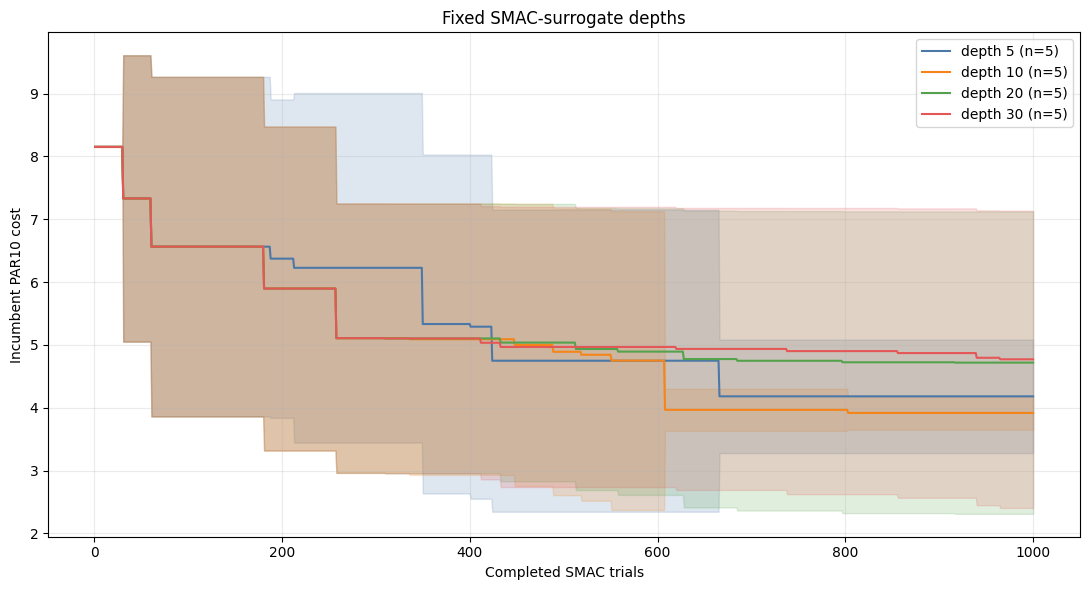

In [13]:
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(1, N_TRIALS + 1)
for depth in DEPTHS:
    selected = [run['trajectory'] for run in runs if run['depth'] == depth]
    if not selected:
        continue
    matrix = np.vstack(selected)
    mean = np.full(N_TRIALS, np.nan)
    half_width = np.full(N_TRIALS, np.nan)
    for index in range(N_TRIALS):
        values = matrix[:, index]
        values = values[np.isfinite(values)]
        if len(values):
            mean[index] = values.mean()
        if len(values) > 1:
            half_width[index] = t.ppf(0.975, len(values) - 1) * values.std(ddof=1) / np.sqrt(len(values))
    ax.plot(x, mean, color=COLORS[depth], label=f'depth {depth} (n={len(selected)})')
    lower = mean - half_width
    ax.fill_between(x, lower, mean + half_width, color=COLORS[depth], alpha=0.18)
ax.set(xlabel='Completed SMAC trials', ylabel='Incumbent PAR10 cost', title='Fixed SMAC-surrogate depths')
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

## Incumbent cost for each SMAC seed

Each panel compares all four surrogate depths for one SMAC seed. Costs are recomputed over the common 100-instance set and shown on a linear y-axis.

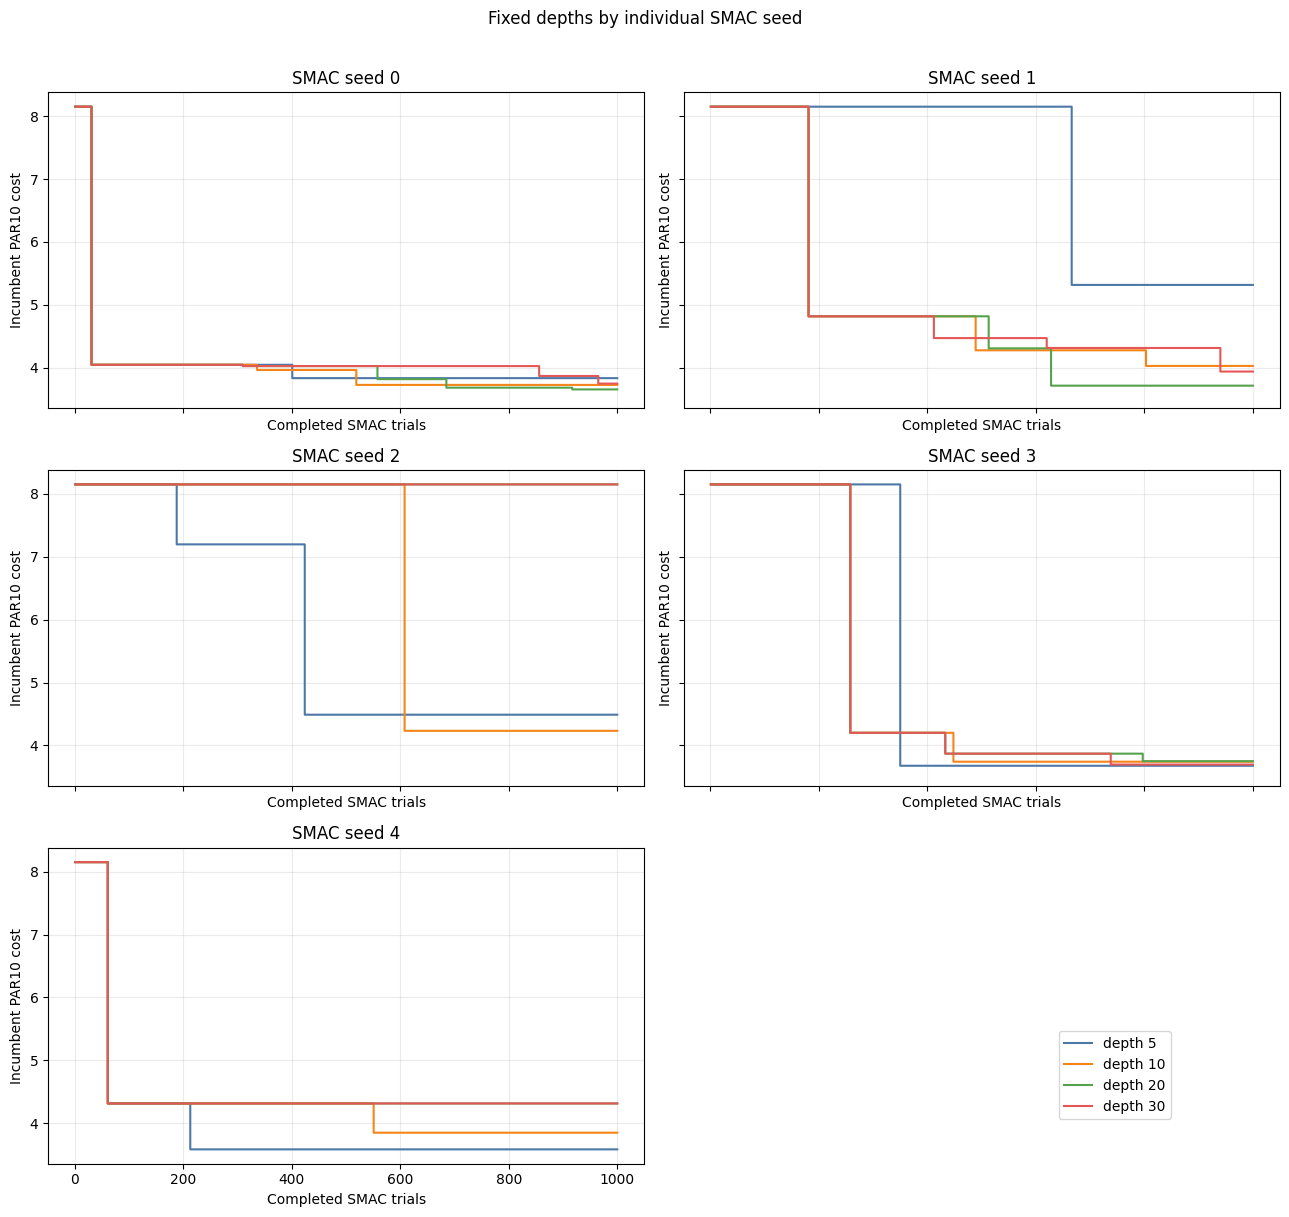

In [14]:
fig, axes = plt.subplots(3, 2, figsize=(13, 12), sharex=True, sharey=True)
x = np.arange(1, N_TRIALS + 1)
for ax, smac_seed in zip(axes.flat, SMAC_SEEDS):
    for depth in DEPTHS:
        selected = [run for run in runs if run['depth'] == depth and run['smac_seed'] == smac_seed]
        if selected:
            ax.step(x, selected[0]['trajectory'], where='post', color=COLORS[depth], label=f'depth {depth}')
    ax.set_title(f'SMAC seed {smac_seed}')
    ax.set_xlabel('Completed SMAC trials')
    ax.set_ylabel('Incumbent PAR10 cost')
    ax.grid(alpha=0.25)
axes.flat[-1].axis('off')
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right', bbox_to_anchor=(0.91, 0.08))
fig.suptitle('Fixed depths by individual SMAC seed', y=1.01)
plt.tight_layout()
plt.show()

## Seed-level boxplots at budget checkpoints

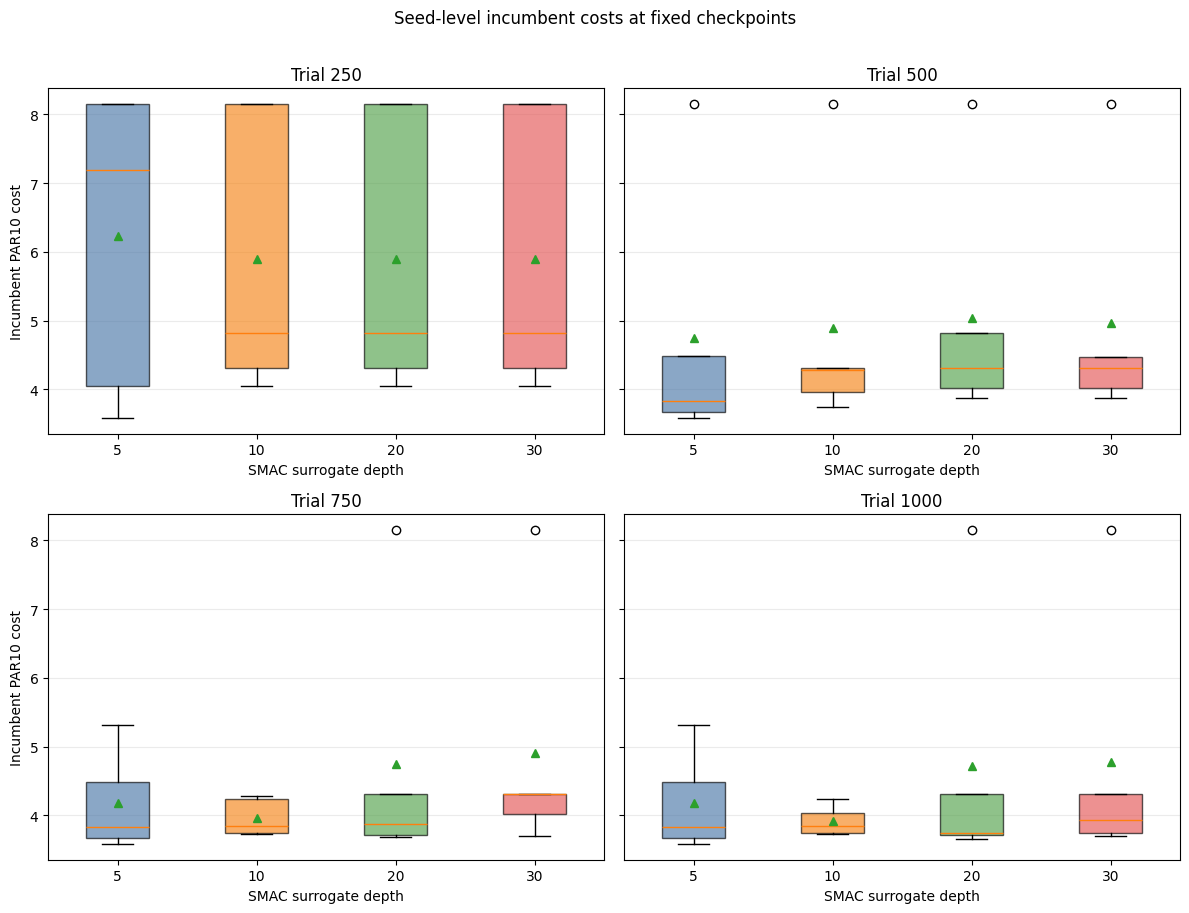

In [15]:
checkpoints = (250, 500, 750, 1_000)
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharey=True)
for ax, checkpoint in zip(axes.flat, checkpoints):
    values = [
        [run['trajectory'][checkpoint - 1] for run in runs
         if run['depth'] == depth and np.isfinite(run['trajectory'][checkpoint - 1])]
        for depth in DEPTHS
    ]
    if any(values):
        boxes = ax.boxplot(values, tick_labels=[str(depth) for depth in DEPTHS], patch_artist=True, showmeans=True)
        for box, depth in zip(boxes['boxes'], DEPTHS):
            box.set_facecolor(COLORS[depth])
            box.set_alpha(0.65)
    else:
        ax.text(0.5, 0.5, 'No completed runs', ha='center', va='center', transform=ax.transAxes)
    ax.set_title(f'Trial {checkpoint}')
    ax.set_xlabel('SMAC surrogate depth')
    ax.grid(axis='y', alpha=0.25)
axes[0, 0].set_ylabel('Incumbent PAR10 cost')
axes[1, 0].set_ylabel('Incumbent PAR10 cost')
fig.suptitle('Seed-level incumbent costs at fixed checkpoints', y=1.01)
plt.tight_layout()
plt.show()

## Final performance and ranking

Average rank is computed within each paired SMAC seed before averaging; lower cost and lower rank are better.

In [16]:
if runs_df.empty:
    print('No completed runs available for ranking.')
else:
    pivot = runs_df.pivot(index='smac_seed', columns='depth', values='final_cost')
    paired_ranks = pivot.rank(axis=1, method='average', ascending=True)
    rows = []
    for depth in DEPTHS:
        values = runs_df.loc[runs_df['depth'] == depth, 'final_cost'].to_numpy()
        margin = np.nan
        if len(values) > 1:
            margin = t.ppf(0.975, len(values) - 1) * values.std(ddof=1) / np.sqrt(len(values))
        rows.append({
            'depth': depth,
            'runs': len(values),
            'mean_final_cost': values.mean(),
            '95% CI half-width': margin,
            'median_final_cost': np.median(values),
            'average_paired_rank': paired_ranks[depth].mean() if depth in paired_ranks else np.nan,
        })
    ranking = pd.DataFrame(rows).sort_values(['average_paired_rank', 'mean_final_cost']).reset_index(drop=True)
    ranking.index = ranking.index + 1
    display(ranking.style.format({
        'mean_final_cost': '{:.5g}',
        '95% CI half-width': '{:.5g}',
        'median_final_cost': '{:.5g}',
        'average_paired_rank': '{:.2f}',
    }))
    display(pivot.style.format('{:.5g}'))

,depth,runs,mean_final_cost,95% CI half-width,median_final_cost,average_paired_rank
1,10,5,3.9158,0.266,3.8484,2.20
2,5,5,4.1804,0.90315,3.8347,2.40
3,20,5,4.717,2.4061,3.7501,2.60
4,30,5,4.7698,2.366,3.9396,2.80


depth,5,10,20,30
smac_seed,,,,
0,3.8347,3.7272,3.6555,3.7481
1,5.3172,4.0289,3.7151,3.9396
2,4.4891,4.2326,8.1509,8.1509
3,3.6773,3.7417,3.7501,3.6967
4,3.5836,3.8484,4.3136,4.3136


## Reading the results

Prefer a depth that combines low final cost with a stable trajectory and a good paired rank. With only five SMAC seeds, confidence intervals can be wide; overlapping bands are descriptive and are not a formal significance test.